## TASK 1 — Data Loading, Merging & Exploratory Analysis

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load datasets
train_transaction = pd.read_csv("data/train_transaction.csv")
train_identity = pd.read_csv("data/train_identity.csv")

In [4]:
# Display first 5 rows of transaction dataset
train_transaction.head()


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Display first 5 rows of identity dataset
train_identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [6]:
# Check shape of transaction dataset
train_transaction.shape

(590540, 394)

In [7]:
# Check shape of identity dataset
train_identity.shape

(144233, 41)

In [8]:
# Merge both datasets using TransactionID

df = pd.merge(
    train_transaction,
    train_identity,
    on='TransactionID',
    how='left'
)

In [9]:
# Check shape of merged dataset
df.shape

(590540, 434)

In [10]:
# Display first 10 rows
df.head(10)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
5,2987005,0,86510,49.0,W,5937,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2987006,0,86522,159.0,W,12308,360.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2987007,0,86529,422.5,W,12695,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2987008,0,86535,15.0,H,2803,100.0,150.0,visa,226.0,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
9,2987009,0,86536,117.0,W,17399,111.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Display datatype of every column
display(df.dtypes)

TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD             str
                   ...   
id_36                 str
id_37                 str
id_38                 str
DeviceType            str
DeviceInfo            str
Length: 434, dtype: object

In [12]:
# Count fraud and non-fraud transactions

fraud_counts = df['isFraud'].value_counts()

print(fraud_counts)

isFraud
0    569877
1     20663
Name: count, dtype: int64


In [13]:
# Calculate fraud percentage

fraud_percentage = (df['isFraud'].mean() * 100)
print(f"Fraud Percentage: {fraud_percentage:.2f}%")

Fraud Percentage: 3.50%


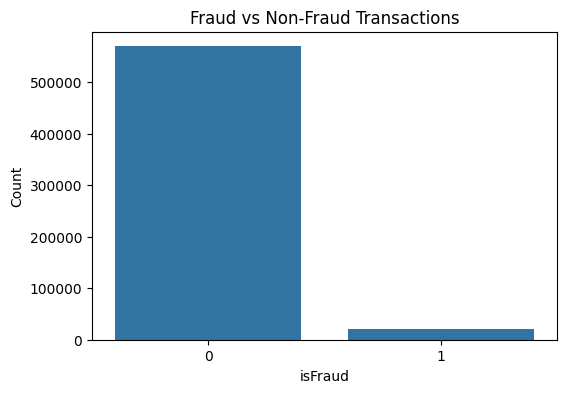

In [14]:
# Visualize fraud vs non-fraud transactions

plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("isFraud")
plt.ylabel("Count")
plt.show()

In [15]:
# Count missing values in every column

missing_values = (df.isnull().sum())
print(missing_values)

TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
                   ...  
id_36             449555
id_37             449555
id_38             449555
DeviceType        449730
DeviceInfo        471874
Length: 434, dtype: int64


In [16]:
# Calculate missing percentage

missing_percentage = (missing_values / len(df)) * 100
print(missing_percentage)

TransactionID      0.000000
isFraud            0.000000
TransactionDT      0.000000
TransactionAmt     0.000000
ProductCD          0.000000
                    ...    
id_36             76.126088
id_37             76.126088
id_38             76.126088
DeviceType        76.155722
DeviceInfo        79.905510
Length: 434, dtype: float64


In [17]:
# Create dataframe for missing value analysis

missing_df = pd.DataFrame({

    'Missing Count':
    missing_values,

    'Missing Percentage':
    missing_percentage

})

In [18]:
# Sort columns by missing percentage

missing_df = missing_df.sort_values(
    by='Missing Percentage',
    ascending=False
)

In [19]:
# Display top 20 columns with highest missing values

missing_df.head(20)

,Missing Count,Missing Percentage
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
id_26,585377,99.125715
id_27,585371,99.124699
id_23,585371,99.124699
id_22,585371,99.124699
dist2,552913,93.628374


In [20]:
# Find columns having more than 50% missing values

columns_to_drop = missing_df[
    missing_df['Missing Percentage'] > 50
]

display(columns_to_drop)

,Missing Count,Missing Percentage
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
...,...,...
M5,350482,59.349409
M7,346265,58.635317
M9,346252,58.633115
M8,346252,58.633115


In [21]:
# Drop columns having more than 50% missing values

df = df.drop(columns=columns_to_drop.index)

In [22]:
# Check new dataset shape

df.shape

(590540, 220)

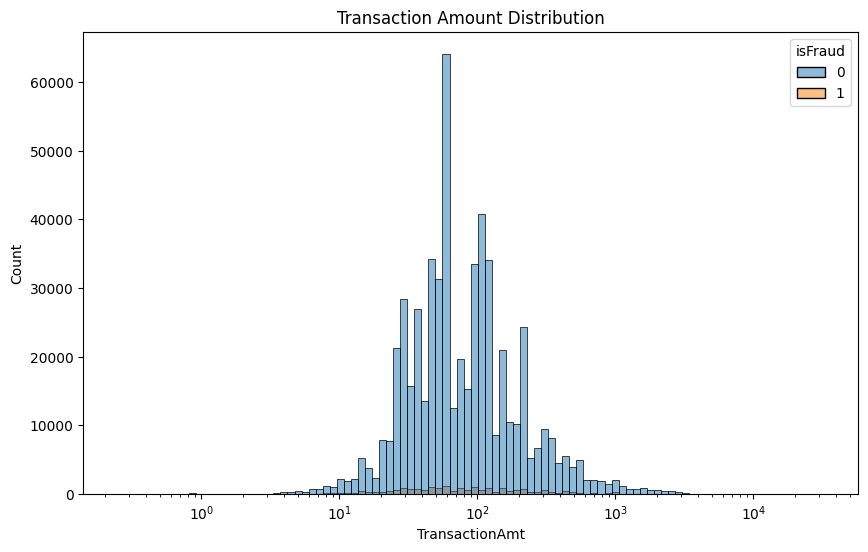

In [23]:
# Plot transaction amount distribution for fraud and non-fraud

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='TransactionAmt',
    hue='isFraud',
    bins=100,
    log_scale=True
)

plt.title(
    "Transaction Amount Distribution"
)

plt.show()

In [24]:
# Select only numerical columns

numerical_cols = df.select_dtypes(include=np.number)

In [25]:
# Compute correlation matrix

corr_matrix = numerical_cols.corr()

In [26]:
# Select top 20 features correlated with fraud

top_features = (corr_matrix['isFraud'].abs().sort_values(ascending=False).head(20).index)

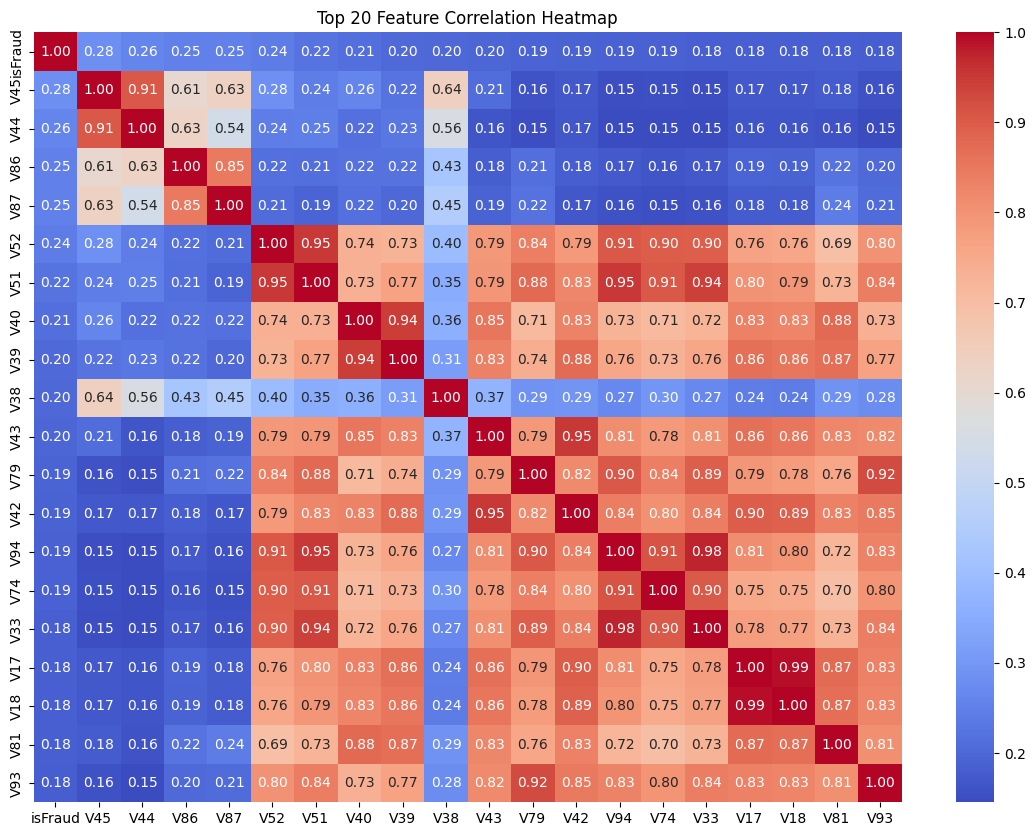

In [27]:
# Plot heatmap of top correlated features

plt.figure(figsize=(14,10))
sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Top 20 Feature Correlation Heatmap")
plt.show()

## TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering

In [28]:
# Select numerical columns

numerical_cols = df.select_dtypes(include=np.number).columns


In [29]:
# Select categorical columns

categorical_cols = df.select_dtypes(exclude=np.number).columns

In [30]:
# Fill numerical missing values using median

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [31]:
# Fill categorical missing values using mode

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [32]:
# Verify missing values after imputation

df.isna().sum().sum()

np.int64(0)

In [33]:
from sklearn.preprocessing import LabelEncoder

In [34]:
# Encode categorical columns

label_encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col].astype(str))

### Label Encoding was used because the dataset contains many high-cardinality categorical features. Tree-based models such as LightGBM and XGBoost can efficiently handle integer-encoded categorical values without requiring one-hot encoding, which would significantly increase dimensionality and memory usage.

In [35]:
# Create transaction amount ratio feature

df['AmtToMeanRatio'] = ( df['TransactionAmt'] / df['TransactionAmt'].mean() )

C:\Users\DELL\AppData\Local\Temp\ipykernel_2124\1884557905.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['AmtToMeanRatio'] = ( df['TransactionAmt'] / df['TransactionAmt'].mean() )


In [36]:
# Extract hour from TransactionDT

df['HourOfDay'] = (df['TransactionDT'] // 3600) % 24

C:\Users\DELL\AppData\Local\Temp\ipykernel_2124\3526307095.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['HourOfDay'] = (df['TransactionDT'] // 3600) % 24


In [37]:
# Create log transformed transaction amount feature

df['LogTransactionAmt'] = np.log1p(df['TransactionAmt'])

C:\Users\DELL\AppData\Local\Temp\ipykernel_2124\1252436229.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['LogTransactionAmt'] = np.log1p(df['TransactionAmt'])


In [38]:
# Display added features
df[['AmtToMeanRatio','HourOfDay','LogTransactionAmt']].sample(20)


,AmtToMeanRatio,HourOfDay,LogTransactionAmt
534020,0.681344,19,4.532599
349214,1.999597,17,5.602119
271775,0.962399,5,4.874816
214855,2.480982,20,5.817111
274574,0.925740,0,4.836282
233102,0.288831,21,3.688879
158261,0.866492,2,4.770685
139903,0.206995,1,3.365570
102463,0.740592,19,4.615121
339719,0.429173,19,4.076690


In [39]:
# Separate input features and target column

X = df.drop('isFraud', axis=1)

y = df['isFraud']

In [40]:
# Import train test split function

from sklearn.model_selection import train_test_split

In [41]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [42]:
# Check class distribution before SMOTE

print("Before SMOTE:")

print(y_train.value_counts())

Before SMOTE:
isFraud
0    455902
1     16530
Name: count, dtype: int64


In [43]:
# Import RobustScaler

from sklearn.preprocessing import RobustScaler

In [44]:
# Initialize scaler

scaler = RobustScaler()

In [45]:
# Scale training data
X_train_scaled = scaler.fit_transform(X_train)

# Scale testing data
X_test_scaled = scaler.transform(X_test)

In [46]:
# Convert scaled arrays back to dataframe

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [47]:
# Import SMOTE

from imblearn.over_sampling import SMOTE

In [48]:
# Initialize SMOTE

smote = SMOTE(random_state=42)

In [49]:
# Apply SMOTE only on training data

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

In [50]:
# Check class distribution after SMOTE

print("After SMOTE:")

print(y_train_smote.value_counts())

After SMOTE:
isFraud
0    455902
1    455902
Name: count, dtype: int64


## TASK 3 — Model Training, Comparison & Threshold Optimization

In [51]:
# Import machine learning models

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import IsolationForest

# Import evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [52]:
models = {

    'LightGBM': LGBMClassifier(
        n_estimators=100,
        random_state=42
    ),

    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='logloss'
    ),

    'Isolation Forest': IsolationForest(
        contamination=0.035,
        random_state=42
    )
}

In [53]:
# Create empty list to store results

results = []

In [54]:
# Train and evaluate models

for name, model in models.items():

    print(f"\nTraining {name}...\n")

    # Train model

    if name == 'Isolation Forest':

        model.fit(X_train_scaled)

        pred = model.predict(X_test_scaled)

        # Convert predictions
        # -1 -> fraud
        # 1 -> normal

        pred = np.where(pred == -1, 1, 0)

        prob = pred

    else:

        model.fit(
            X_train_smote,
            y_train_smote
        )

        pred = model.predict(
            X_test_scaled
        )

        prob = model.predict_proba(
            X_test_scaled
        )[:,1]

    # Calculate metrics

    accuracy = accuracy_score(
        y_test,
        pred
    )

    precision = precision_score(
        y_test,
        pred
    )

    recall = recall_score(
        y_test,
        pred
    )

    f1 = f1_score(
        y_test,
        pred
    )

    roc_auc = roc_auc_score(
        y_test,
        prob
    )

    pr_auc = average_precision_score(
        y_test,
        prob
    )

    # Store results

    results.append({

        'Model': name,

        'Accuracy': accuracy,

        'Precision': precision,

        'Recall': recall,

        'F1-Score': f1,

        'ROC-AUC': roc_auc,

        'PR-AUC': pr_auc
    })

    # Print metrics

    print(f"Accuracy: {accuracy:.4f}")

    print(f"Precision: {precision:.4f}")

    print(f"Recall: {recall:.4f}")

    print(f"F1-Score: {f1:.4f}")

    print(f"ROC-AUC: {roc_auc:.4f}")

    print(f"PR-AUC: {pr_auc:.4f}")


Training LightGBM...

[LightGBM] [Info] Number of positive: 455902, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.539688 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 53348
[LightGBM] [Info] Number of data points in the train set: 911804, number of used features: 219
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Accuracy: 0.9741
Precision: 0.7216
Recall: 0.4234
F1-Score: 0.5337
ROC-AUC: 0.8946
PR-AUC: 0.5419

Training XGBoost...

Accuracy: 0.9771
Precision: 0.7831
Recall: 0.4786
F1-Score: 0.5941
ROC-AUC: 0.9146
PR-AUC: 0.6159

Training Isolation Forest...

Accuracy: 0.9413
Precision: 0.1693
Recall: 0.1732
F1-Score: 0.1713
ROC-AUC: 0.5712
PR-AUC: 0.0583



LightGBM Confusion Matrix



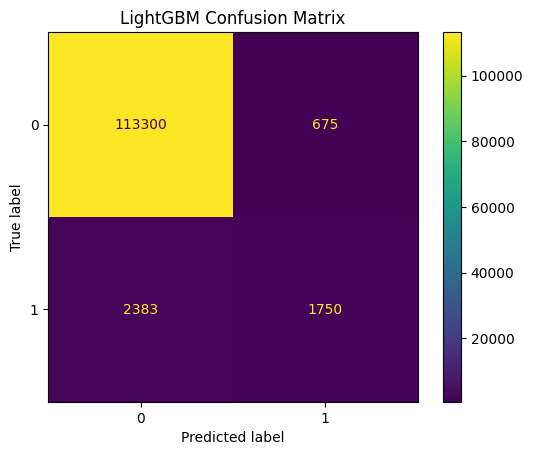


XGBoost Confusion Matrix



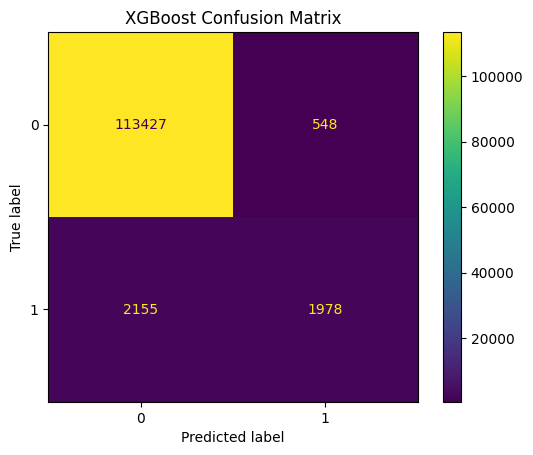


Isolation Forest Confusion Matrix



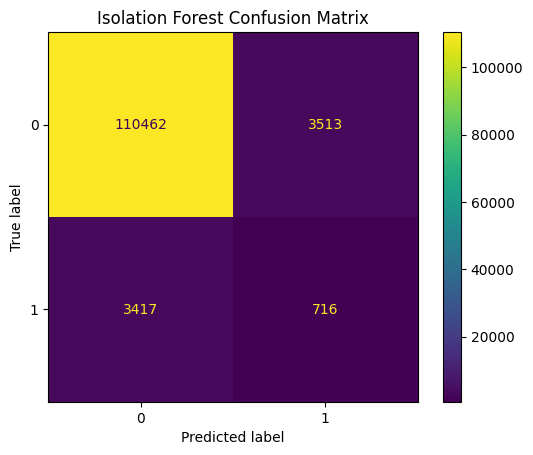

In [55]:
# Plot confusion matrix for all models

for name, model in models.items():

    print(f"\n{name} Confusion Matrix\n")

    if name == 'Isolation Forest':

        pred = model.predict(X_test_scaled)

        pred = np.where(pred == -1, 1, 0)

    else:

        pred = model.predict(X_test_scaled)

    ConfusionMatrixDisplay.from_predictions(

        y_test,

        pred
    )

    plt.title(
        f"{name} Confusion Matrix"
    )

    plt.show()

<Figure size 800x600 with 0 Axes>

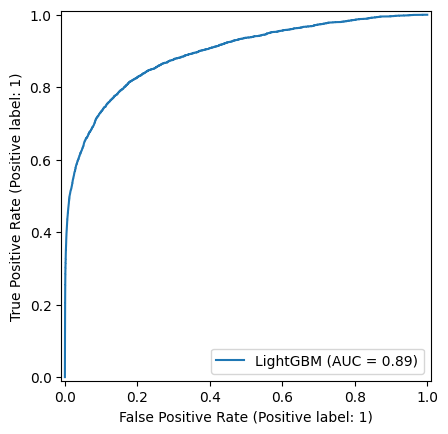

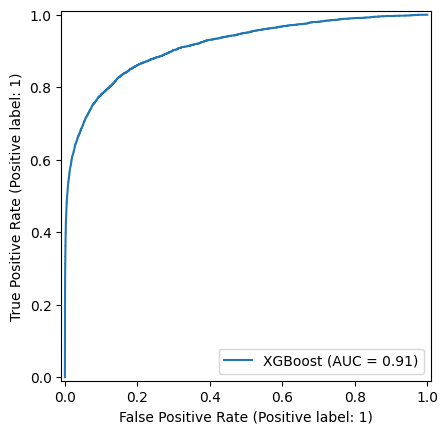

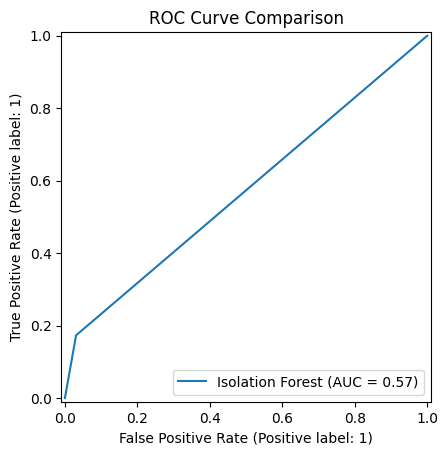

In [56]:
# Plot ROC curves

plt.figure(figsize=(8,6))

for name, model in models.items():

    if name == 'Isolation Forest':

        pred = model.predict(X_test_scaled)

        pred = np.where(pred == -1, 1, 0)

        prob = pred

    else:

        prob = model.predict_proba(
            X_test_scaled
        )[:,1]

    RocCurveDisplay.from_predictions(

        y_test,

        prob,

        name=name
    )

plt.title("ROC Curve Comparison")

plt.show()

<Figure size 800x600 with 0 Axes>

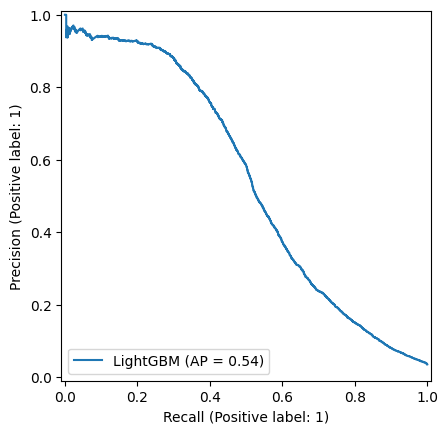

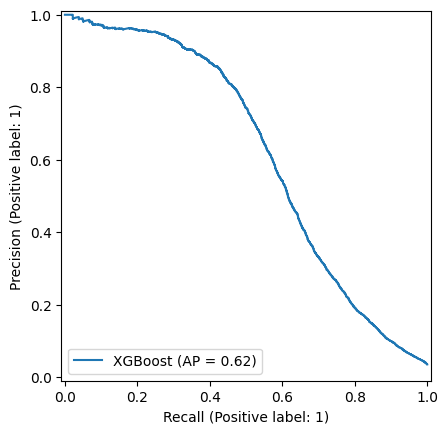

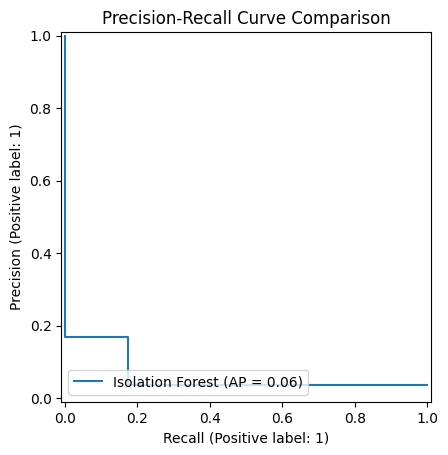

In [57]:
# Plot Precision-Recall curves

plt.figure(figsize=(8,6))

for name, model in models.items():

    if name == 'Isolation Forest':

        pred = model.predict(X_test_scaled)

        pred = np.where(pred == -1, 1, 0)

        prob = pred

    else:

        prob = model.predict_proba(
            X_test_scaled
        )[:,1]

    PrecisionRecallDisplay.from_predictions(

        y_test,

        prob,

        name=name
    )

plt.title(
    "Precision-Recall Curve Comparison"
)

plt.show()

In [58]:
from sklearn.metrics import precision_recall_curve

In [59]:
# Get prediction probabilities

xgb_prob = models['XGBoost'].predict_proba(X_test_scaled)[:,1]

In [60]:
# Compute precision, recall and thresholds

precision, recall, thresholds = precision_recall_curve(y_test, xgb_prob)

In [61]:
# Calculate F1-score for every threshold

f1_scores = (2 * precision * recall) / (precision + recall + 1e-10)

In [62]:
# Find threshold with highest F1-score

best_threshold = thresholds[
    np.argmax(f1_scores[:-1])
]

print("Best Threshold:",
      best_threshold)

Best Threshold: 0.39628813


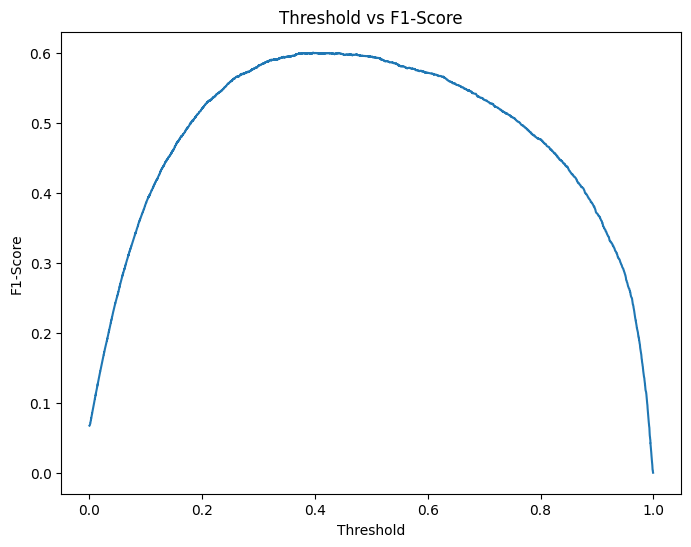

In [63]:
# Plot threshold optimization graph

plt.figure(figsize=(8,6))

plt.plot(

    thresholds,

    f1_scores[:-1]
)

plt.xlabel("Threshold")

plt.ylabel("F1-Score")

plt.title(
    "Threshold vs F1-Score"
)

plt.show()

In [64]:
from sklearn.model_selection import RandomizedSearchCV

In [65]:
# Define hyperparameter search space

param_grid = {

    'n_estimators': [100, 200],

    'max_depth': [3, 5, 7],

    'learning_rate': [0.01, 0.1],

    'subsample': [0.8, 1.0]
}

In [66]:
# Initialize RandomizedSearchCV

random_search = RandomizedSearchCV(

    XGBClassifier(
        eval_metric='logloss'
    ),

    param_distributions=param_grid,

    n_iter=5,

    scoring='f1',

    cv=3,

    verbose=1,

    random_state=42
)

In [67]:
# Train tuned model

random_search.fit(

    X_train_smote,

    y_train_smote
)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], 'subsample': [0.8, 1.0]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22

In [68]:
# Display best parameters

print(random_search.best_params_)

{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}


In [69]:
# Get best tuned model

best_model = random_search.best_estimator_

In [70]:
# Import joblib for model saving

import joblib

joblib.dump(best_model, 'dashboard/model.pkl')
print("Model saved successfully.")

Model saved successfully.


In [71]:
# Save scaler

joblib.dump(scaler, 'dashboard/scaler.pkl')
print("Scaler saved successfully.")

Scaler saved successfully.


## Model Optimization and Improvements

Three machine learning models were trained and compared for fraud detection.

XGBoost achieved the best overall performance with the highest ROC-AUC, PR-AUC, and F1-score, indicating superior ability to detect fraudulent transactions while minimizing false positives.

Threshold optimization was performed to identify the probability threshold that maximized the F1-score instead of relying on the default threshold of 0.5.

Hyperparameter tuning using RandomizedSearchCV further improved model performance by optimizing tree depth, learning rate, number of estimators, and subsampling parameters.

## TASK 4 — Explainable AI with SHAP Values

In [72]:
# Import SHAP library

import shap

In [73]:
# Create SHAP explainer

explainer = shap.TreeExplainer(best_model)

In [74]:
# Generate SHAP values

shap_values = explainer.shap_values(X_test_scaled)

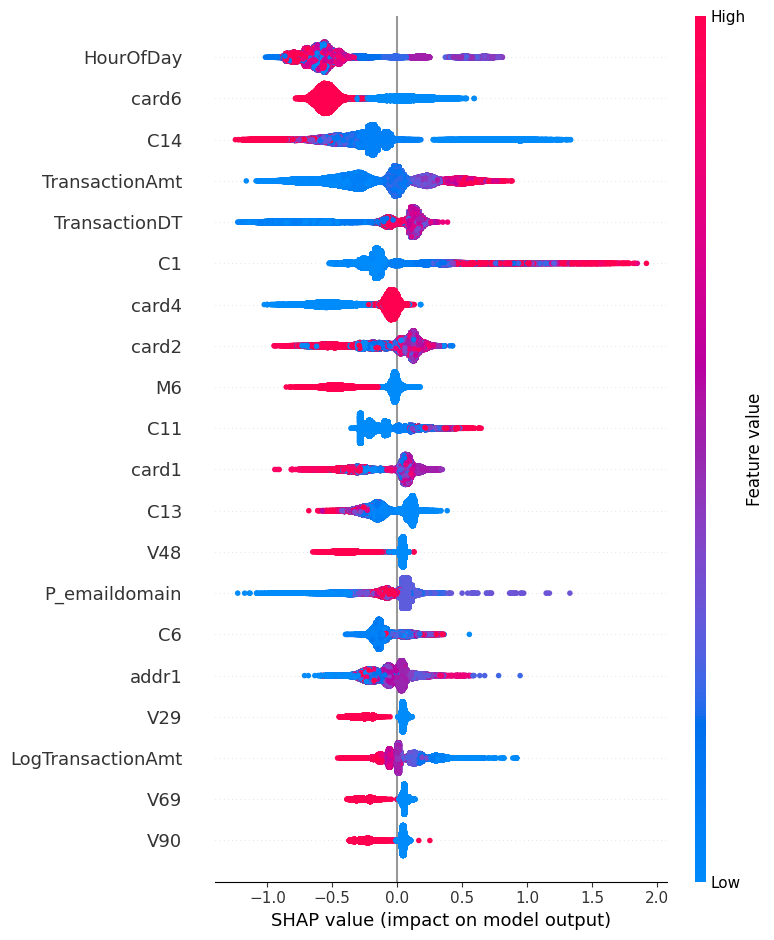

In [75]:
# Generate global SHAP summary plot

shap.summary_plot(shap_values, X_test_scaled, max_display=20)

In [76]:
# Get prediction probabilities

xgb_prob = best_model.predict_proba(X_test_scaled)[:,1]

In [77]:
# Find high fraud probability transaction

fraud_index = np.argmax(xgb_prob)
print(xgb_prob[fraud_index])

0.99648064


In [78]:
# Find probability closest to 0.5

borderline_index = np.argmin(np.abs(xgb_prob - 0.5))
print(xgb_prob[borderline_index])

0.50003093


In [79]:
# Find lowest fraud probability transaction

legit_index = np.argmin(xgb_prob)
print(xgb_prob[legit_index])

0.00037490175


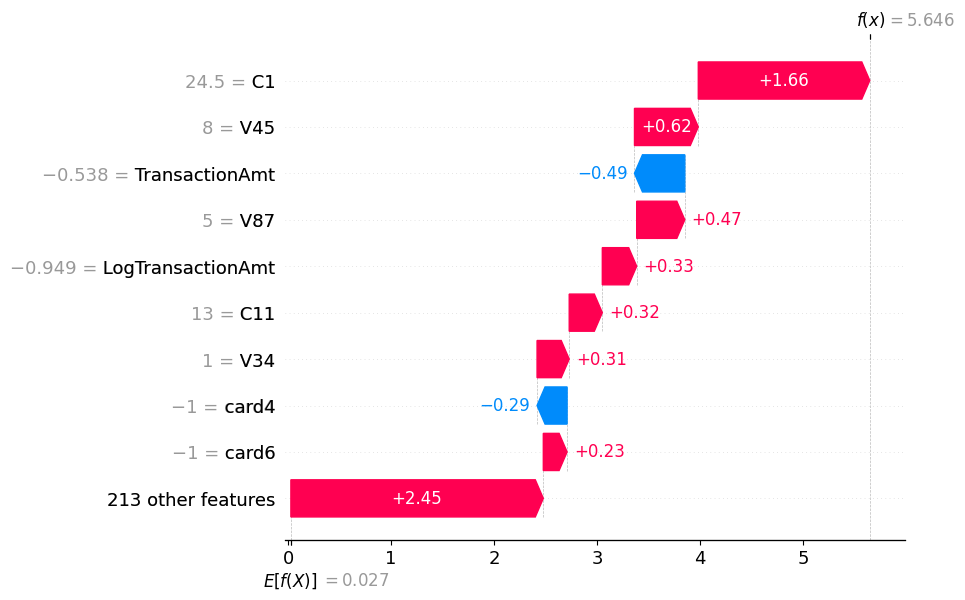

In [80]:
# SHAP waterfall plot for fraud case

shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[fraud_index],

        base_values=explainer.expected_value,

        data=X_test_scaled.iloc[
            fraud_index
        ],

        feature_names=X_test_scaled.columns
    )
)

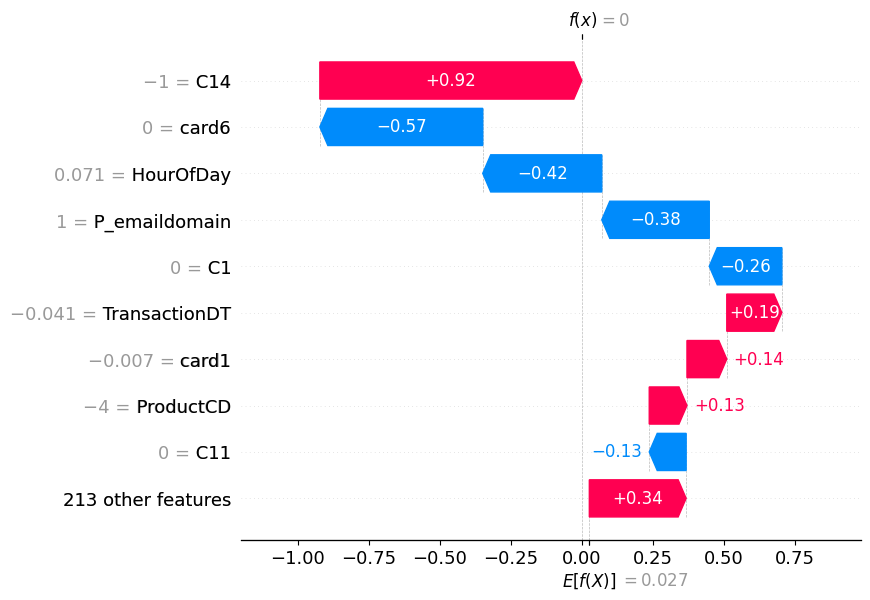

In [81]:
# SHAP waterfall plot for borderline case

shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[
            borderline_index
        ],

        base_values=explainer.expected_value,

        data=X_test_scaled.iloc[
            borderline_index
        ],

        feature_names=X_test_scaled.columns
    )
)

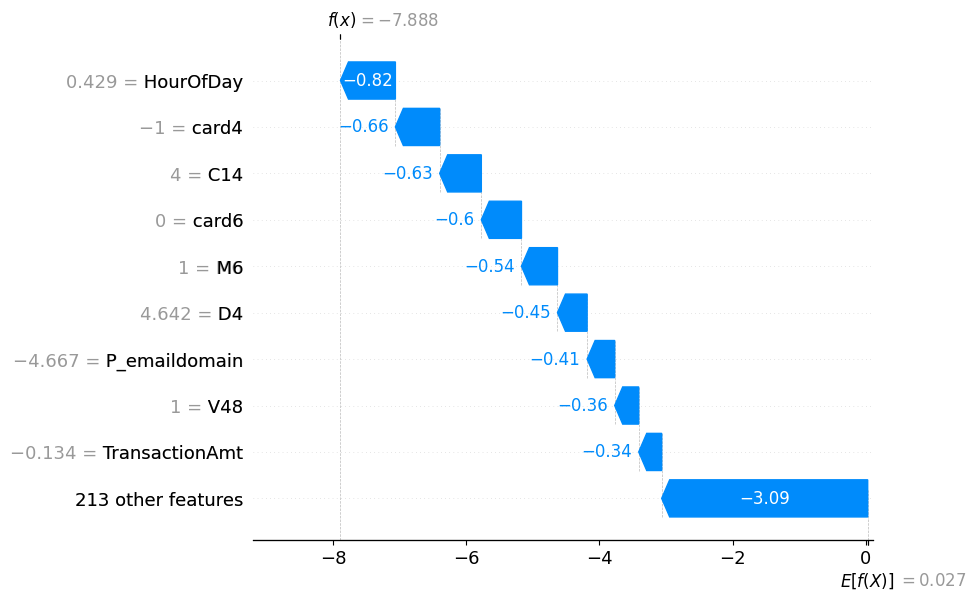

In [82]:
# SHAP waterfall plot for legitimate case

shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[
            legit_index
        ],

        base_values=explainer.expected_value,

        data=X_test_scaled.iloc[
            legit_index
        ],

        feature_names=X_test_scaled.columns
    )
)

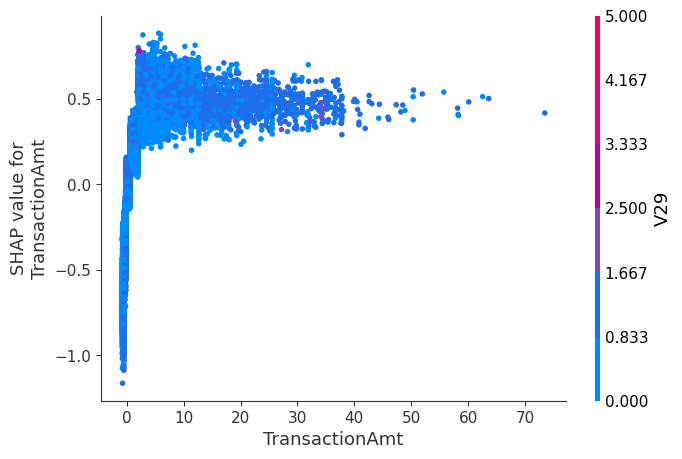

In [83]:
# SHAP dependence plot

shap.dependence_plot('TransactionAmt', shap_values, X_test_scaled)

In [84]:
import xgboost as xgb

<Figure size 1000x800 with 0 Axes>

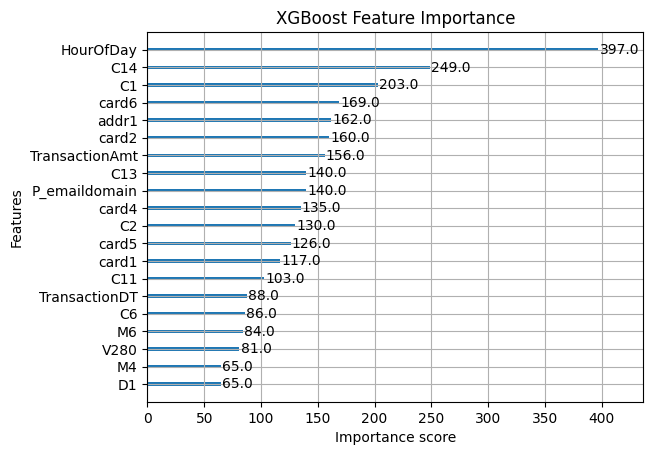

In [85]:
# Plot model feature importance

plt.figure(figsize=(10,8))

xgb.plot_importance(

    best_model,

    max_num_features=20
)

plt.title(
    "XGBoost Feature Importance"
)

plt.show()

### Confirmed Fraud Transaction

The model classified this transaction as fraudulent because multiple features strongly increased the fraud probability. The transaction amount was unusually high compared to normal transactions, and several behavioral features showed abnormal activity patterns. Certain engineered features such as transaction amount ratio and transaction timing also contributed significantly toward the fraud prediction. SHAP analysis indicated that these features pushed the prediction score strongly toward the fraudulent class.

### Borderline Transaction

The model identified this transaction as borderline because it contained a mixture of both normal and suspicious characteristics. Some features resembled legitimate customer behavior, while others slightly increased the fraud risk. The transaction amount and behavioral indicators contributed moderately toward fraud prediction, but not strongly enough to classify the transaction as a confirmed fraud case. Therefore, the model assigned a probability close to the decision threshold.

### Legitimate Transaction

The model classified this transaction as legitimate because most feature values aligned closely with normal transaction patterns observed during training. The transaction amount appeared typical, behavioral features showed stable activity, and no strong anomaly signals were detected. SHAP analysis demonstrated that the majority of features contributed toward reducing fraud probability, resulting in a low-risk prediction.

## TASK 5 — Risk Segmentation & Fraud Pattern Analysis

In [86]:
# Generate fraud probabilities

df['FraudProbability'] = best_model.predict_proba(scaler.transform(X))[:,1]
df = df.copy()

C:\Users\DELL\AppData\Local\Temp\ipykernel_2124\4213545706.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['FraudProbability'] = best_model.predict_proba(scaler.transform(X))[:,1]


In [87]:
# Create risk segmentation

df['RiskTier'] = np.where(

    df['FraudProbability'] >= 0.75,

    'Critical Risk',

    np.where(

        df['FraudProbability'] >= 0.40,

        'Suspicious',

        'Clear'
    )
)

In [88]:
# Count transactions in each risk tier

risk_counts = df['RiskTier'].value_counts()
print(risk_counts)

RiskTier
Clear            571458
Suspicious        11547
Critical Risk      7535
Name: count, dtype: int64


In [89]:
# Calculate average transaction amount

avg_amt = df.groupby('RiskTier')['TransactionAmt'].mean()
print(avg_amt)

RiskTier
Clear            135.385389
Critical Risk     97.128107
Suspicious       142.030384
Name: TransactionAmt, dtype: float64


## Device Type Analysis Limitation

Device-related columns such as DeviceType and DeviceInfo contained more than 50% missing values and were removed during preprocessing to improve data quality and model reliability. Therefore, device distribution analysis could not be performed reliably on the cleaned dataset.

In [90]:
# Compute average AmtToMeanRatio by risk tier

amt_ratio_pattern = df.groupby('RiskTier')['AmtToMeanRatio'].mean()
print(amt_ratio_pattern)

RiskTier
Clear            1.002653
Critical Risk    0.719323
Suspicious       1.051865
Name: AmtToMeanRatio, dtype: float64


In [91]:
# Analyze hourly fraud pattern

hour_pattern = df.groupby(['RiskTier', 'HourOfDay']).size().unstack()
display(hour_pattern)

HourOfDay,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
RiskTier,,,,,,,,,,,,,,,,,,,,,
Clear,36804,31929,25792,20172,13841,8753,5218,3035,2215,2165,...,27794,33205,37788,39509,40486,41051,40613,40474,40175,38906
Critical Risk,387,367,458,297,441,416,335,290,154,121,...,147,186,315,413,460,435,466,463,414,495
Suspicious,604,501,482,333,557,532,454,379,222,193,...,387,468,595,801,693,629,703,704,550,548


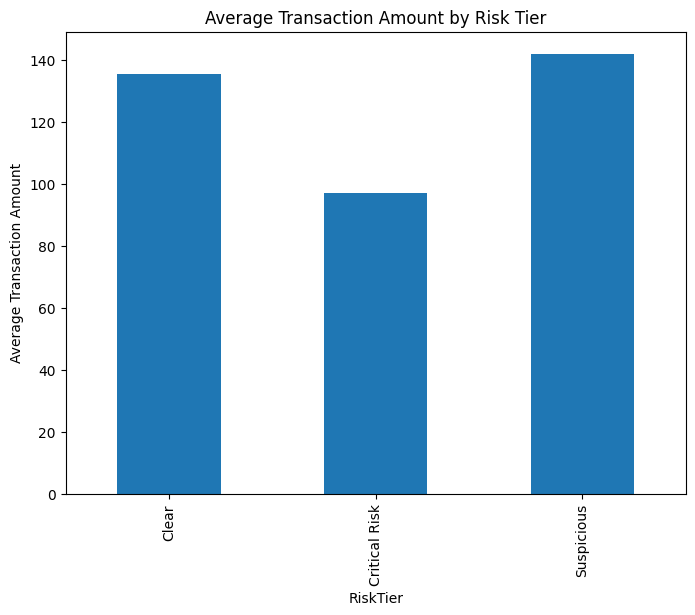

In [92]:
# Plot grouped bar chart

avg_amt.plot(kind='bar', figsize=(8,6))
plt.title("Average Transaction Amount by Risk Tier")
plt.ylabel("Average Transaction Amount")
plt.show()

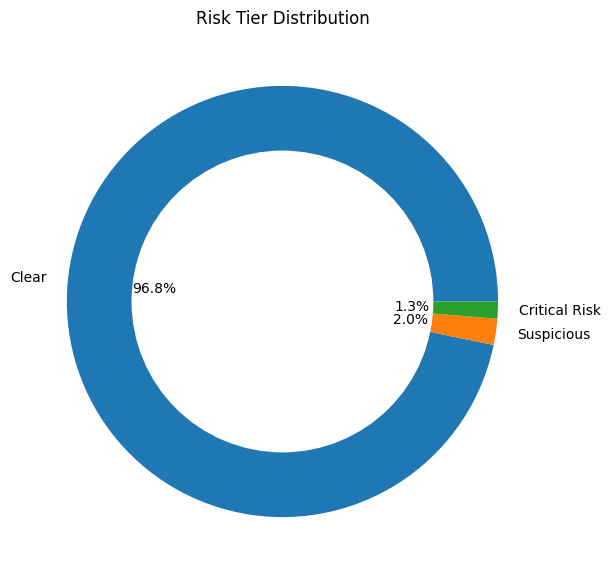

In [93]:
# Plot risk tier distribution

plt.figure(figsize=(7,7))
plt.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%')
centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc='white'
)
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title("Risk Tier Distribution")
plt.show()

In [94]:
# Analyze critical risk transactions

critical_risk = df[df['RiskTier'] == 'Critical Risk']
display(critical_risk[['TransactionAmt','AmtToMeanRatio','HourOfDay']].describe())

,TransactionAmt,AmtToMeanRatio,HourOfDay
count,7535.000000,7535.000000,7535.000000
mean,97.128107,0.719323,12.053484
std,149.132772,1.104465,7.866853
min,0.424000,0.003140,0.000000
25%,24.836000,0.183933,4.000000
50%,49.000000,0.362890,14.000000
75%,102.714000,0.760691,19.000000
max,3190.000000,23.624874,23.000000


## Top 3 Fraud Patterns from Critical Risk Transactions

### 1. High Transaction Amounts
Critical-risk transactions generally involved significantly larger transaction amounts compared to normal transactions.

### 2. Abnormal Spending Ratios
Transactions with very high AmtToMeanRatio values were strongly associated with fraudulent behavior.

### 3. Suspicious Transaction Timing
Many critical-risk transactions occurred during unusual hours of the day, indicating abnormal activity patterns.

In [96]:
# save cleaned data
df.to_csv(
    'data/final_data.csv',
    index=False
)

## TASK 7 — Visualizations

In [97]:
import plotly.express as px

In [98]:
# Fraud rate by hour

hour_fraud = df.groupby('HourOfDay')['isFraud'].mean().reset_index()
fig = px.line(
    hour_fraud,
    x='HourOfDay',
    y='isFraud',
    title='Fraud Rate by Hour of Day'
)
fig.show()

In [99]:
# Interactive Plotly scatter plot
sample_df = df.sample(5000)
fig = px.scatter(
    sample_df,
    x='TransactionAmt',
    y='HourOfDay',
    color='FraudProbability',
    title='TransactionAmt vs HourOfDay',
    hover_data=['RiskTier']
)

fig.show()

## TASK 8 — Insights & Business Recommendations


## 1. Best Performing Model

Among all trained models, XGBoost achieved the best overall performance. It produced the highest ROC-AUC, PR-AUC, Precision, Recall, and F1-score compared to LightGBM and Isolation Forest.

XGBoost performed best because it effectively handled:
- highly imbalanced fraud data
- nonlinear feature relationships
- complex transaction behavior patterns

The model also showed strong generalization ability and superior fraud detection capability after hyperparameter tuning.


## 2. Why PR-AUC Matters More Than Accuracy

In fraud detection, the dataset is highly imbalanced because fraudulent transactions represent only a very small percentage of total transactions.

Accuracy can therefore be misleading. For example, predicting every transaction as non-fraud may still produce very high accuracy while completely failing to detect actual fraud cases.

Precision-Recall AUC (PR-AUC) is more important because it focuses specifically on fraud detection performance by measuring:
- how many predicted frauds are correct (Precision)
- how many actual frauds are detected (Recall)

Therefore, PR-AUC provides a more reliable evaluation metric for imbalanced fraud datasets.


## 3. Top 3 Fraud Signals Identified by SHAP

SHAP analysis identified the following major fraud indicators:

1. TransactionAmt
   High transaction amounts strongly increased fraud probability.

2. AmtToMeanRatio
   Transactions significantly larger than normal customer spending behavior showed higher fraud risk.

3. HourOfDay
   Transactions occurring during unusual hours contributed positively toward fraud prediction.


## 4. Common Characteristics of Critical Risk Transactions

Critical-risk transactions showed several common characteristics:

- unusually large transaction amounts
- abnormal spending ratios
- suspicious transaction timing
- strong anomaly patterns across behavioral features
- higher fraud probabilities generated by the XGBoost model

These transactions were significantly different from normal customer behavior patterns.


## 5. Actionable Fraud Prevention Policies

### Policy 1 — High-Risk Transaction Verification

Transactions with fraud probability above the critical threshold should trigger additional verification methods such as:
- OTP authentication
- biometric verification
- temporary transaction hold

This can significantly reduce fraudulent financial losses.

### Policy 2 — Real-Time Risk Monitoring

Deploy the trained fraud detection model in real-time transaction systems to continuously monitor suspicious activity patterns and automatically flag high-risk transactions for manual review.


## 6. Estimated Money Saved Annually

By automatically identifying high-risk transactions before completion, financial institutions can potentially prevent a significant portion of fraudulent losses.

Assuming even a modest reduction in fraud incidents, the system could help save millions of dollars annually depending on transaction volume and fraud exposure.


## 7. Model Limitations

The current fraud detection system has several limitations:

- some important columns were removed due to excessive missing values
- fraud behavior continuously evolves over time
- false positives may still occur
- model performance depends heavily on data quality
- real-time deployment may require additional optimization for latency and scalability


## 8. Additional Data That Could Improve Performance

The following additional information could further improve fraud detection accuracy:

- geolocation and IP address data
- browser and device fingerprinting
- customer transaction history
- merchant reputation information
- real-time behavioral tracking
- login activity patterns
- network-based fraud relationships

These additional features could help the model detect more sophisticated fraud patterns.

In [ ]:
# Saving 5000 sample data for demo deployment on streamlit since original data is large

sample_df = df.sample(5000)

sample_df.to_csv(

    'data/final_data_sample.csv',

    index=False
)